In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Cargar datos
df = pd.read_csv("../data/raw/breast_cancer.csv")
X = df.drop('target', axis=1)
y = df['target']

In [3]:
# Cargar modelos y scaler
with open("models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("models/final_model.pkl", "rb") as f:
    modelo = pickle.load(f)

# Preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Todo cargado correctamente")

Todo cargado correctamente


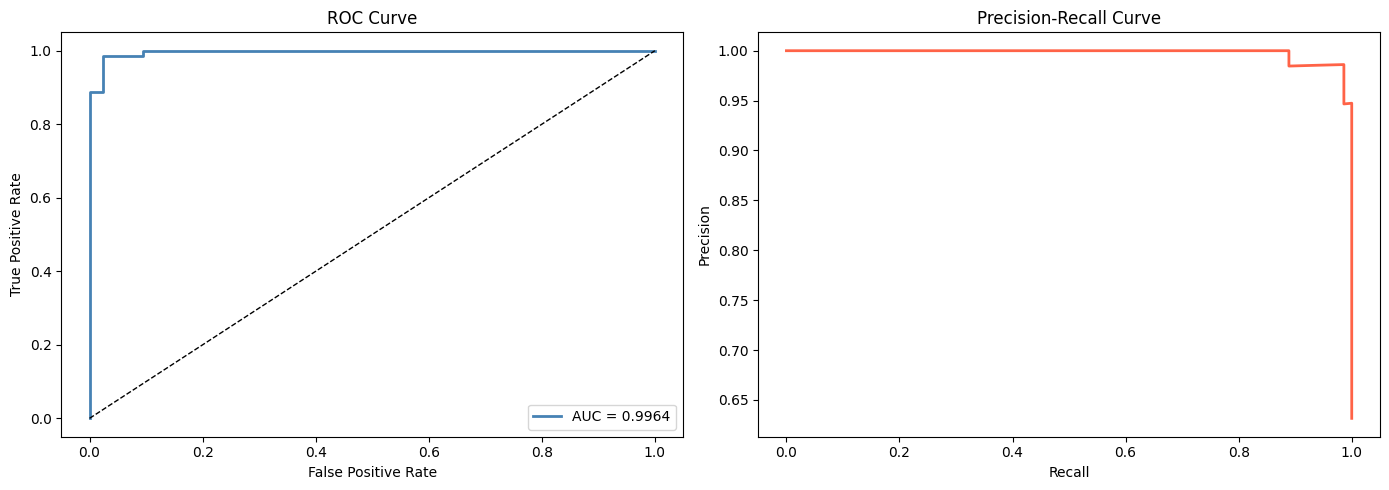

In [4]:
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='tomato', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

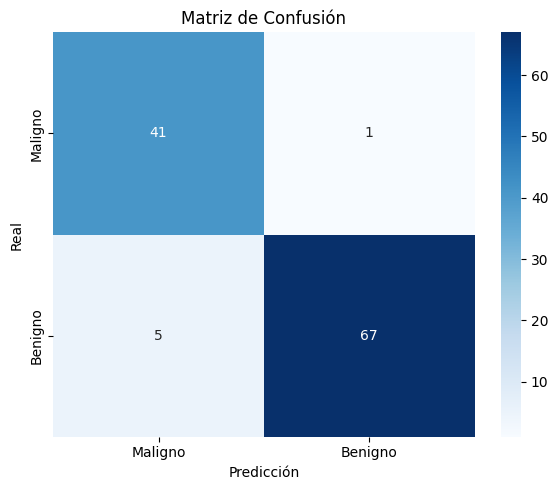

              precision    recall  f1-score   support

     Maligno       0.89      0.98      0.93        42
     Benigno       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [6]:
y_pred = modelo.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Maligno', 'Benigno'],
    yticklabels=['Maligno', 'Benigno']
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

## Evaluación Final del Modelo

**ROC AUC: 0.9964** — el modelo distingue malignos de benignos con 99.64% de efectividad.

**Matriz de Confusión:**
- 41 verdaderos positivos (malignos correctamente identificados)
- 67 verdaderos negativos (benignos correctamente identificados)  
- 1 falso negativo (maligno clasificado como benigno) ← error crítico
- 5 falsos positivos (benignos clasificados como malignos)

El modelo presenta un comportamiento conservador: prefiere clasificar como 
maligno ante la duda, lo cual es clínicamente deseable ya que minimiza los 
falsos negativos. El único falso negativo representa un caso límite que 
requeriría validación con estudios adicionales en un entorno real.

**Limitación importante:** este modelo es una herramienta de apoyo diagnóstico 
y no debe reemplazar el criterio clínico de un especialista.

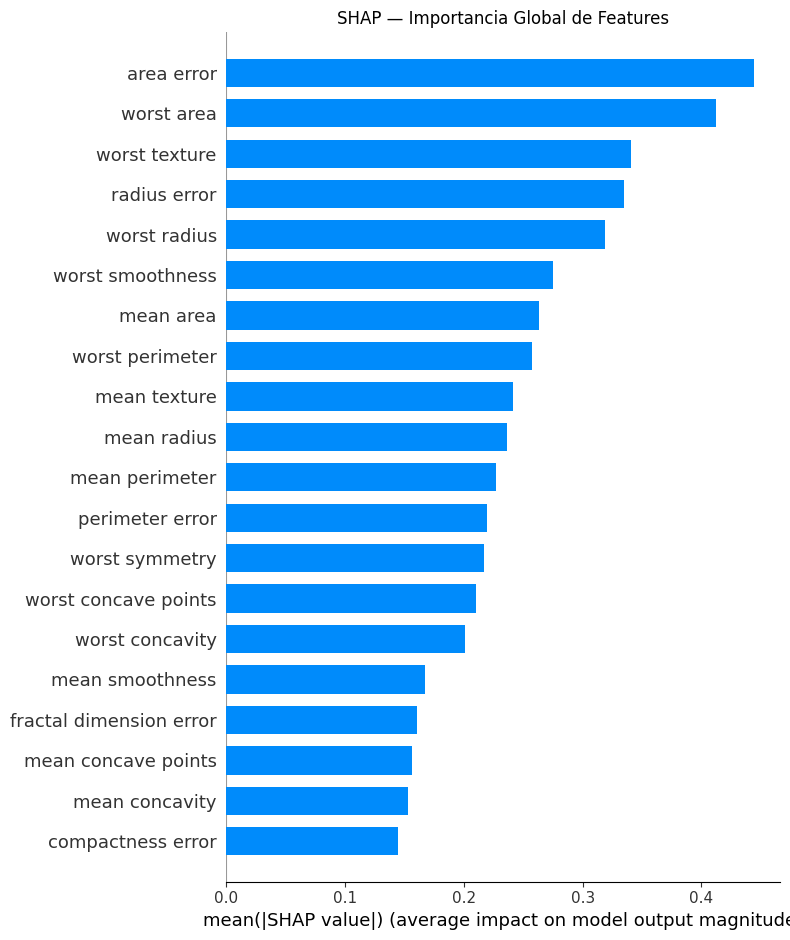

In [8]:
# SHAP values globales
explainer = shap.LinearExplainer(modelo, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Convertir a DataFrame para tener nombres de columnas
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Summary plot — importancia global de features
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importancia Global de Features")
plt.tight_layout()
plt.show()

## SHAP — Interpretabilidad Global

Contrario a lo predicho en el EDA, las features de área (`area error`, `worst area`) 
y error de radio (`radius error`) son las más influyentes para el modelo, no las 
de concavidad.

Esto sugiere que la **irregularidad en el tamaño de los núcleos** (capturada por 
los errores estándar) es la señal más fuerte de malignidad en este dataset, 
por encima de la forma del contorno nuclear.

`worst concave points`, que visualmente mostraba la mejor separación en el pairplot, 
aparece en el top 15 pero no domina — lo que ilustra que la importancia visual 
en 2D no siempre se traduce directamente en importancia para el modelo en 
el espacio completo de 30 dimensiones.

Índice del falso negativo: [53]


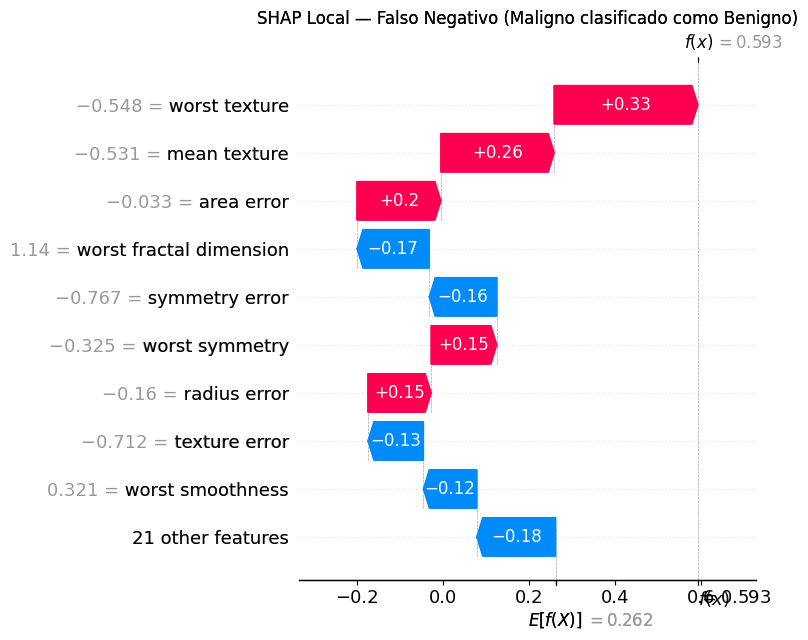

In [10]:
# SHAP local — explicar una predicción individual
# Tomamos el caso del falso negativo (maligno clasificado como benigno)
y_pred = modelo.predict(X_test_scaled)
falsos_negativos = np.where((y_test.values == 0) & (y_pred == 1))[0]
print(f"Índice del falso negativo: {falsos_negativos}")

# Waterfall plot del caso más interesante
idx = falsos_negativos[0]
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[idx],
        feature_names=X.columns.tolist()
    ),
    show=False
)
plt.title("SHAP Local — Falso Negativo (Maligno clasificado como Benigno)")
plt.tight_layout()
plt.show()

La conclusión clínica:
Este tumor maligno tenía características atípicas — sus valores de textura y área apuntaban a maligno, pero su fractal dimension, simetría y suavidad eran inusualmente similares a un tumor benigno. Es un caso límite genuinamente difícil, no un error grave del modelo.

## SHAP Local — Análisis del Falso Negativo

El único falso negativo del modelo (maligno clasificado como benigno) obtuvo 
una probabilidad de 0.593 hacia benigno — apenas por encima del umbral de 0.5.

Las features de textura (`worst texture` +0.33, `mean texture` +0.26) empujaban 
correctamente hacia maligno, pero fueron superadas por `worst fractal dimension` 
(-0.17), `symmetry error` (-0.16) y el conjunto de features restantes (-0.18) 
que apuntaban hacia benigno.

Este caso representa un tumor con morfología atípica — sus características de 
tamaño y textura son malignas, pero su forma y simetría se asemejan a un tumor 
benigno. En un entorno clínico real, este caso requeriría estudios adicionales 
independientemente de la predicción del modelo.